<a href="https://colab.research.google.com/github/Karthikeya81/OPENCV_LAB_RECORD/blob/main/Experiment_7_(edge_detection_methods).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment - 7  (edge detection methods)

Please upload an image to detect edges (Sudoku or a clear object works well!):


Saving sudoku.png to sudoku.png

--- Original Grayscale ---


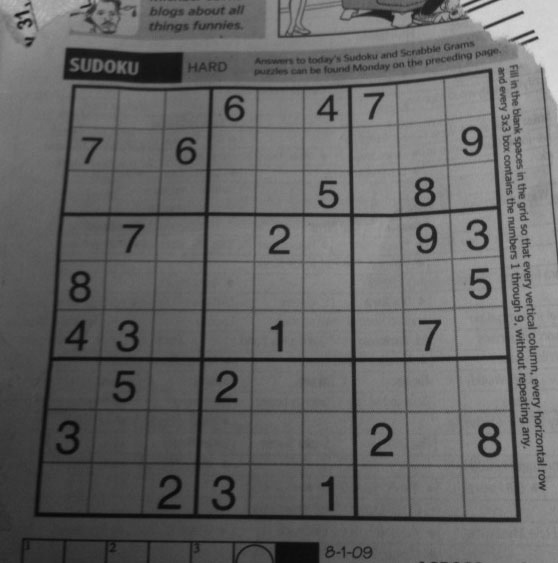


--- 1. Sobel X (Finds Vertical Edges) ---


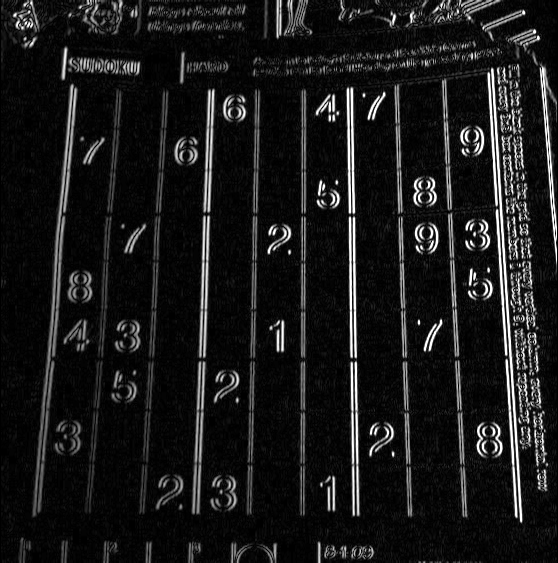


--- 2. Sobel Y (Finds Horizontal Edges) ---


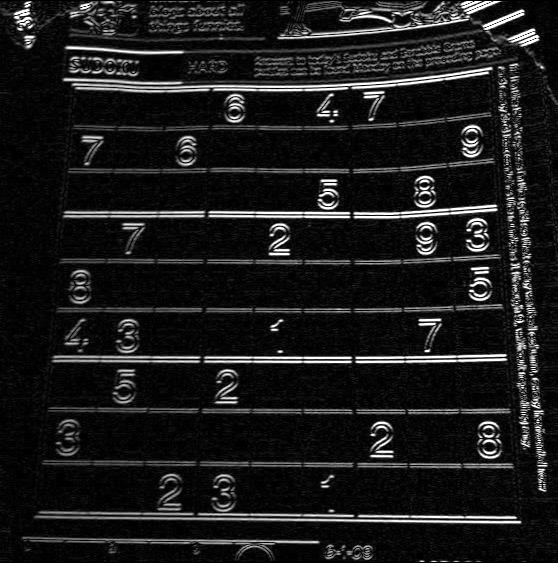


--- 3. Sobel Combined ---


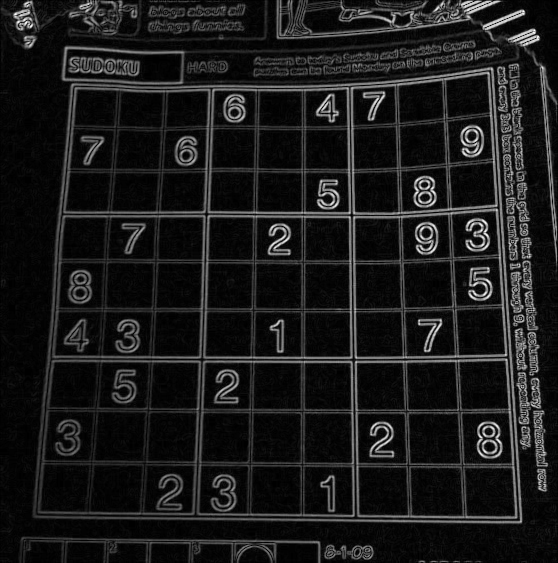


--- 4. Laplacian ---


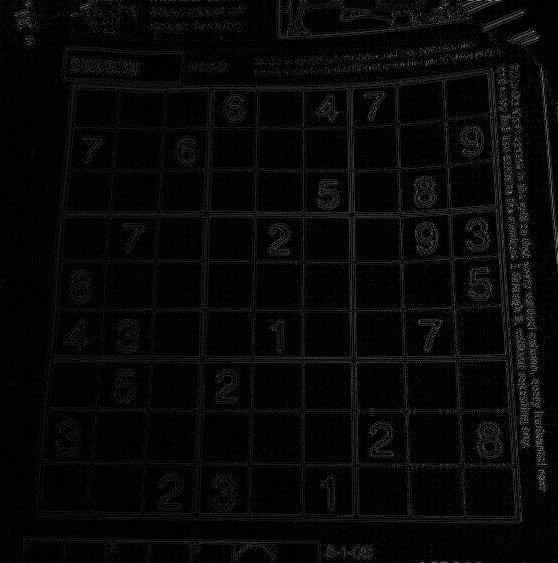


--- 5. Canny (The Gold Standard) ---


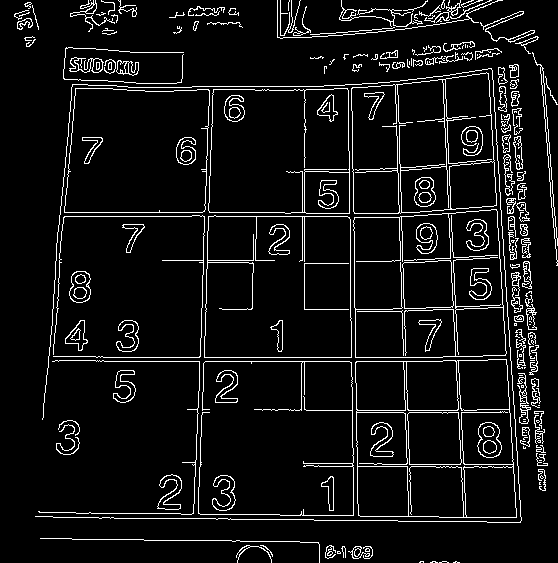

In [1]:
# --- Task 1 & 2: Import tools and read image in grayscale ---
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

print("Please upload an image to detect edges (Sudoku or a clear object works well!):")
uploaded = files.upload()
filename = next(iter(uploaded))

# Read the image directly in grayscale
gray_image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# --- Task 3: Apply Sobel (X and Y) ---
# We use cv2.CV_64F (64-bit float) instead of standard 8-bit.
# Why? Because transitioning from White-to-Black is a negative number!
# If we don't use 64F, OpenCV will just turn those negative slopes to 0 and we miss half the edges.
sobel_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3) # 1, 0 means X-direction
sobel_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=3) # 0, 1 means Y-direction

# Convert back to standard 8-bit unsigned integers so we can display them
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

# Combine X and Y to get a full picture of the edges
sobel_combined = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)


# --- Task 4: Apply Laplacian ---
# Laplacian calculates the 2nd derivative to find edges in all directions at once
laplacian = cv2.Laplacian(gray_image, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)


# --- Task 5: Apply Canny ---
# Canny is a multi-step algorithm. It requires a minimum and maximum threshold.
# Any edge stronger than 200 is definitely an edge. Anything below 100 is ignored.
canny = cv2.Canny(gray_image, 100, 200)


# --- Task 6: Display all outputs ---
print("\n--- Original Grayscale ---")
cv2_imshow(gray_image)

print("\n--- 1. Sobel X (Finds Vertical Edges) ---")
cv2_imshow(sobel_x)

print("\n--- 2. Sobel Y (Finds Horizontal Edges) ---")
cv2_imshow(sobel_y)

print("\n--- 3. Sobel Combined ---")
cv2_imshow(sobel_combined)

print("\n--- 4. Laplacian ---")
cv2_imshow(laplacian)

print("\n--- 5. Canny (The Gold Standard) ---")
cv2_imshow(canny)